# Proyecto 7 - Explorando factores de comportamiento en NovaRetail+


NovaRetail+ es una plataforma de comercio electrónico en Latinoamérica con millones de usuarios.

Para el cierre de 2024, el equipo de **Crecimiento y retención** tiene como objetivo responder:

**¿Qué factores del comportamiento del cliente están más fuertemente asociados con el ingreso anual generado?**

> Este proyecto es un análisis **correlacional** (exploratorio).  
> **Correlación ≠ causalidad.**

## Sección 1 - Cargar y explorar el dataset

En esta sección validamos:
- que el dataset cargue correctamente
- tipos de datos
- valores faltantes / rangos generales

Antes de correlacionar, primero entendemos el “terreno”.

In [9]:
# Importar librerías
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pointbiserialr
from scipy.stats import chi2_contingency

### Cargar Dataset

In [10]:
# Cargar el dataset y explorar datos
df = pd.read_csv('/datasets/novaretail_comportamiento_clientes_2024.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id_cliente                 15000 non-null  object 
 1   edad                       15000 non-null  float64
 2   nivel_ingreso              15000 non-null  float64
 3   visitas_mes                15000 non-null  int64  
 4   compras_mes                15000 non-null  int64  
 5   gasto_publicidad_dirigida  15000 non-null  float64
 6   satisfaccion               15000 non-null  float64
 7   miembro_premium            15000 non-null  int64  
 8   abandono                   15000 non-null  int64  
 9   tipo_dispositivo           15000 non-null  object 
 10  region                     15000 non-null  object 
 11  ingreso_anual              15000 non-null  float64
dtypes: float64(5), int64(4), object(3)
memory usage: 1.4+ MB


#### Descripción del conjunto de datos

El dataset contiene las siguientes columnas:

- `id_cliente` — Identificador único del cliente.
- `edad` — Edad del cliente.
- `nivel_ingreso` — Ingreso anual estimado del cliente.
- `visitas_mes` — Número de visitas a la aplicación o sitio web durante el mes.
- `compras_mes` — Número de compras realizadas en el mes.
- `gasto_publicidad_dirigida` — Gasto en anuncios asignado al usuario.
- `satisfaccion` — Calificación de satisfacción del cliente en una escala del 1 al 5.
- `miembro_premium` — Indica si el cliente tiene suscripción premium (1) o no (0).
- `abandono` — Indica si el cliente abandonó la plataforma (1) o no (0).
- `tipo_dispositivo` — Tipo de dispositivo utilizado por el cliente (móvil, escritorio o tablet).
- `region` — Región geográfica del cliente (norte, sur, oeste o este).
- `ingreso_anual` — Ingreso anual generado por el cliente para la empresa.

La métrica principal de análisis es `ingreso_anual`, utilizada para evaluar el impacto económico de los clientes.


In [11]:
# mostrar las primeras 5 filas
df.head()

,id_cliente,edad,nivel_ingreso,visitas_mes,compras_mes,gasto_publicidad_dirigida,satisfaccion,miembro_premium,abandono,tipo_dispositivo,region,ingreso_anual
0,CL-100000,44.0,28565.77,9,1,31.36,3.9,0,0,móvil,norte,23.22
1,CL-100001,36.0,29673.44,11,3,24.66,3.7,0,0,tablet,sur,93.47
2,CL-100002,46.0,30642.95,9,0,0.00,2.9,0,0,móvil,este,0.00
3,CL-100003,56.0,39468.61,8,0,6.81,3.1,0,0,móvil,este,0.00
4,CL-100004,35.0,22527.83,9,2,26.49,2.3,0,0,móvil,sur,33.76


## Sección 2 - Preparar datos y documentar supuestos

### Exploración y Limpieza

#### Exploración inicial de los datos
El conjunto de datos contiene **15,000 registros** y **12 columnas**, sin valores nulos.

**Variables numéricas**  
Se identifican las siguientes columnas numéricas:
- `edad`
- `nivel_ingreso`
- `visitas_mes`
- `compras_mes`
- `gasto_publicidad_dirigida`
- `satisfaccion`
- `ingreso_anual`

Todas las columnas presentan un tipo de dato adecuado para el análisis correlacional, por lo que no es necesario realizar cambios en esta etapa.

**Variables binarias**  
Las siguientes columnas representan variables binarias:
- `miembro_premium`
- `abandono`

Ambas están codificadas como 0 y 1, **no requieren transformación adicional**.

**Variables categóricas**  
Se identifican las siguientes columnas categóricas:

- `id_cliente`
- `tipo_dispositivo`
- `region`

Estas variables están correctamente definidas y no requieren transformación adicional.

In [12]:
# Corregir el tipo de dato


In [13]:
# verificar cambios
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id_cliente                 15000 non-null  object 
 1   edad                       15000 non-null  float64
 2   nivel_ingreso              15000 non-null  float64
 3   visitas_mes                15000 non-null  int64  
 4   compras_mes                15000 non-null  int64  
 5   gasto_publicidad_dirigida  15000 non-null  float64
 6   satisfaccion               15000 non-null  float64
 7   miembro_premium            15000 non-null  int64  
 8   abandono                   15000 non-null  int64  
 9   tipo_dispositivo           15000 non-null  object 
 10  region                     15000 non-null  object 
 11  ingreso_anual              15000 non-null  float64
dtypes: float64(5), int64(4), object(3)
memory usage: 1.4+ MB


#### Explorar variables numéricas

In [14]:
# Estadísticas descriptivas de variables numéricas
columnas_numericas = [
    'edad',
    'nivel_ingreso',
    'visitas_mes',
    'compras_mes',
    'gasto_publicidad_dirigida',
    'satisfaccion',
    'ingreso_anual'
]
df[columnas_numericas].describe()

,edad,nivel_ingreso,visitas_mes,compras_mes,gasto_publicidad_dirigida,satisfaccion,ingreso_anual
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,38.262400,30019.704782,10.029000,1.206467,20.149301,3.603693,36.594180
std,11.492378,9833.166305,3.158189,1.105284,10.880724,0.685300,34.484888
min,18.000000,8000.000000,1.000000,0.000000,0.000000,1.000000,0.000000
25%,30.000000,23127.097500,8.000000,0.000000,12.310000,3.100000,0.000000
50%,38.000000,30023.745000,10.000000,1.000000,19.730000,3.600000,30.705000
75%,46.000000,36768.440000,12.000000,2.000000,27.292500,4.100000,58.220000
max,75.000000,74790.840000,25.000000,8.000000,75.510000,5.000000,244.690000


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico.  
Incluye qué ves (resalta un detalle relevante por columna)

### Diagnóstico inicial de variables numéricas

- `edad` — Los clientes tienen entre **18 y 75 años**, con una media y mediana de **38 años**, lo que sugiere una distribución equilibrada de edades.

- `nivel_ingreso` — El ingreso estimado presenta una amplia variabilidad (de **8,000** a **74,790.84**). La cercanía entre la media y la mediana indica una distribución estable.

- `visitas_mes` — Los usuarios realizan en promedio **10 visitas mensuales**.

- `compras_mes` — Al menos el **25 % de los clientes no realizó ninguna compra** durante el período analizado.

- `gasto_publicidad_dirigida` — La inversión publicitaria por cliente presenta una dispersión grande.

- `satisfaccion` — La satisfacción promedio es de **3.6** sobre **5**, lo que implica una percepción generalmente positiva con margen de mejora.

- `ingreso_anual` — Se observa que **al menos el 25 % de los clientes no generó ingresos**, algo que es congruente con la estadística de `compras_mes`. Por otro lado, esto sugiere la presencia de clientes de alto valor y una distribución sesgada hacia valores altos.

#### Explorar variables binarias

In [15]:
# Verificar que cada columna tenga únicamente dos valores posibles
columnas_binarias = ['miembro_premium', 'abandono']
for col in columnas_binarias:
    print(col, df[col].unique())

miembro_premium [0 1]
abandono [0 1]


**Diagnóstico inicial de variables binarias**

- `miembro_premium` & `abandono` ambas columnas están correctamente codificadas ya que ambas sólo contienen '1' & '0'

#### Explorar variables categóricas

In [16]:
# Verificar el número de valores únicos por variable categórica
columnas_categoricas = ['tipo_dispositivo', 'region']
for col in columnas_categoricas:
    print(col, df[col].unique())

tipo_dispositivo ['móvil' 'tablet' 'escritorio']
region ['norte' 'sur' 'este' 'oeste']


In [17]:
# Explorar variables categóricas y cómo se distribuyen
for columna in columnas_categoricas:
    print(f"\n{columna}")
    print(df[columna].value_counts())
    print("\nPorcentaje:")
    print((df[columna].value_counts(normalize=True)*100))


tipo_dispositivo
móvil         9818
escritorio    3720
tablet        1462
Name: tipo_dispositivo, dtype: int64

Porcentaje:
móvil         65.453333
escritorio    24.800000
tablet         9.746667
Name: tipo_dispositivo, dtype: float64

region
norte    4395
oeste    3810
sur      3726
este     3069
Name: region, dtype: int64

Porcentaje:
norte    29.30
oeste    25.40
sur      24.84
este     20.46
Name: region, dtype: float64


**Diagnóstico inicial de variables categóricas**

- `tipo_dispositivo`: **móvil** es el más frecuente y representa aproximadamente el **65%** de los dispositivos utilizados. En contraste, **tablet** representa menos del **10%**.
- `region`: Los ususarios parecen estar distribuidos casi homogeneamente pero hay una ligera mayoría de usuarios en la región **Norte** y una ligera minoría en la región **este** dicha diferencia no es mayor al 5% respecto al valor esperado.

### Supuestos

- El análisis se realiza utilizando **todo el conjunto de datos disponible**.
- Los datos no presentan errores y están correctamente tipificados.
- Se utilizan distintos coeficientes según el tipo de variable:
  - **Pearson** asume relaciones lineales entre variables numéricas.
  - **Spearman** evalúa relaciones monótonas y no requiere normalidad.
  - **Punto biserial** se usa para relaciones numérica–binaria.
  - **Cramér (V)** se usa para asociaciones entre variables categóricas.

**Supuesto central:**  
Este análisis identifica relaciones entre variables o segmentos, pero no prueba causalidad.

## Sección 3 - Visualización de relaciones

Observamos cómo se relacionan las variables numéricas.

### Heatmap

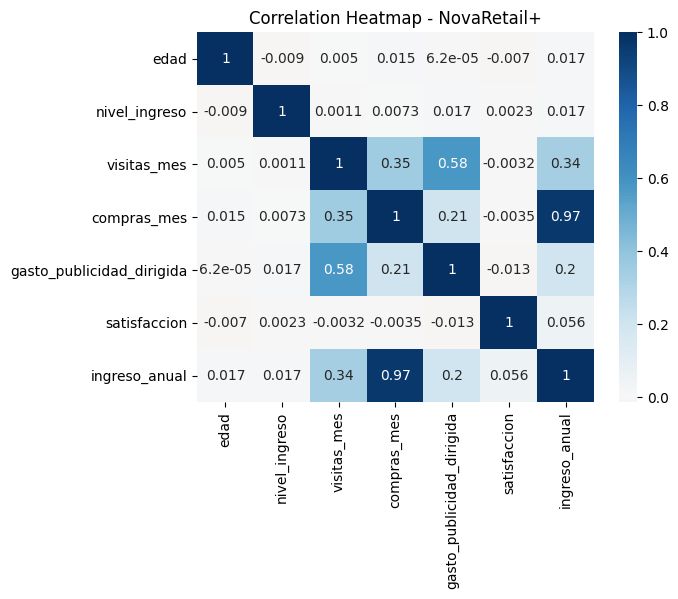

In [18]:
# Visualizar la matriz de correlación para identificar relaciones
corr = df[columnas_numericas].corr()

sns.heatmap(corr, annot=True, cmap="RdBu", center=0)
plt.title("Correlation Heatmap - NovaRetail+")
plt.show()

### Observaciones generales (Heatmap)

- Se observa una **correlación positiva muy fuerte** entre `compras_mes` e `ingreso_anual` (**r = 0.97**), prácticamente se podría considerar **colinealidad** entre ambas variables. Esto se explica porque básicamente las compras de los clientes se traducen en el ingreso que tiene la empresa por parte de los clientes.
- `visitas_mes` presenta una **correlación positiva moderada** con `gasto_publicidad_dirigida` (**r = 0.58**), sugiriendo que los clientes que visitan con mayor frecuencia la plataforma suelen recibir una mayor inversión en publicidad dirigida o visceversa, es decir, podemos estar hablando de un caso de **causalidad reversa**. Se debe analizar a mayor profundidad si en el negocio un cliente recibe mayor publicidad debido a su número de visitas o si es que al recibir mayor publicidad es que tiene un mayor número de visitas.
- La relación entre `visitas_mes` y `compras_mes` es **positiva pero moderada** (**r = 0.35**), indicando que un mayor número de visitas no siempre se traduce en más compras.
- Las correlaciones entre `gasto_publicidad_dirigida` y `compras_mes` (**r = 0.21**) y entre `gasto_publicidad_dirigida` e `ingreso_anual` (**r = 0.20**) son **débiles**, lo que sugiere que la inversión publicitaria, por sí sola, no presenta una asociación fuerte con el comportamiento de compra o el ingreso generado.
- Estos resultados representan **asociaciones estadísticas** y **no deben interpretarse como relaciones causales**. Será necesario complementar el análisis con técnicas adicionales o experimentos para determinar relaciones de causa y efecto.

### Scatterplot general

Con base en los resultados del análisis de correlación, evalúa si es necesario generar un *scatterplot* general.

- **Si decides incluirlo**:
  - Genera el gráfico.
  - Describe brevemente qué patrones o tendencias observas.

- **Si decides no incluirlo**:
  - Explica por qué.

### Scatterplot para pares clave

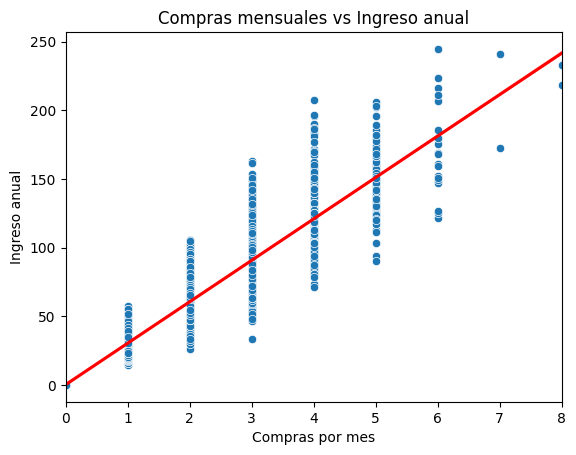

In [19]:
# Visualizar pares de variables con relaciones moderadas o fuertes

sns.scatterplot(data=df, x='compras_mes', y='ingreso_anual')
sns.regplot(data=df, x='compras_mes', y='ingreso_anual',scatter=False,color='red')
plt.title('Compras mensuales vs Ingreso anual')
plt.xlabel('Compras por mes')
plt.ylabel('Ingreso anual')

plt.show()


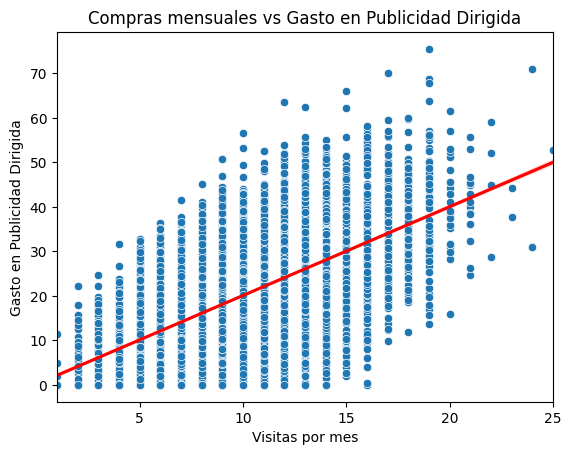

In [20]:
sns.scatterplot(data=df, x='visitas_mes', y='gasto_publicidad_dirigida')
sns.regplot(data=df, x='visitas_mes', y='gasto_publicidad_dirigida',scatter=False,color='red')
plt.title('Compras mensuales vs Gasto en Publicidad Dirigida')
plt.xlabel('Visitas por mes')
plt.ylabel('Gasto en Publicidad Dirigida')

plt.show()

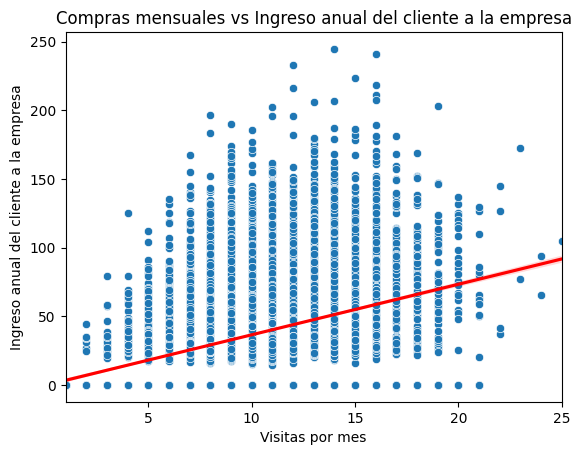

In [21]:
sns.scatterplot(data=df, x='visitas_mes', y='ingreso_anual')
sns.regplot(data=df, x='visitas_mes', y='ingreso_anual',scatter=False,color='red')
plt.title('Compras mensuales vs Ingreso anual del cliente a la empresa')
plt.xlabel('Visitas por mes')
plt.ylabel('Ingreso anual del cliente a la empresa')

plt.show()

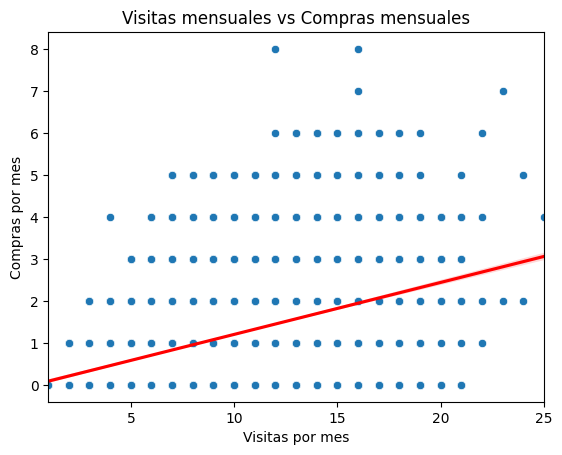

In [22]:
sns.scatterplot(data=df, x='visitas_mes', y='compras_mes')
sns.regplot(data=df, x='visitas_mes', y='compras_mes',scatter=False,color='red')
plt.title('Visitas mensuales vs Compras mensuales')
plt.xlabel('Visitas por mes')
plt.ylabel('Compras por mes')

plt.show()

### Observaciones iniciales (Scatterplot)

**Compras por mes vs Ingreso Anual**
- La correlación es fuerte y positiva, se observa que cuando un cliente hace más compras por mes tiende a reflejarse en mayores ingresos anuales para la empresa.
- Sin embargo, no se observa una sola línea recta, hay puntos que demuestran que no se trata de **colinealidad** y sí de una relación muy fuerte.

**Visitas por mes vs Gasto en publicidad dirigida**
- La correlación es media y positiva, se observa que cuando un cliente hace más visitas por mes va de la mano con haber hecho mayor gasto en publicidad dirigida.
- Sin embargo, no es posible descartar a simple vista que no se trate de un caso de **causalidad reversa** y la empresa esté dirigiendo publicidad hacia a los usuarios con mayor número de visitas.

**Visitas por mes vs Compras por mes**
- La correlación es débil, pero positiva, se observa que cuando un cliente hace más visitas por mes es más probable que haga más compras; y eventualmente eso se convierta en mayores **ingresos anuales**.

## Sección 4 - Coeficientes de correlación y evidencia numérica

En esta sección, se reportan coeficientes que respaldan los patrones
observados visualmente, utilizando el método adecuado según el tipo
de variables.

### Pearson / Spearman

In [23]:
# Calcular correlación entre variables relevantes
method=["pearson","spearman"]

# Escribe aquí la función numeric_corr(df, columnas)
def numeric_corr(df, columnas_numericas):
    pearson_corr = df[columnas_numericas].corr(method="pearson")
    spearman_corr = df[columnas_numericas].corr(method="spearman")

    print("Correlación Pearson:")
    print(pearson_corr)
    print("\nCorrelación Spearman:")
    print(spearman_corr)

# Ejecutar función
numeric_corr(df, columnas_numericas)

Correlación Pearson:
                               edad  nivel_ingreso  visitas_mes  compras_mes  \
edad                       1.000000      -0.009003     0.004998     0.014971   
nivel_ingreso             -0.009003       1.000000     0.001060     0.007309   
visitas_mes                0.004998       0.001060     1.000000     0.353844   
compras_mes                0.014971       0.007309     0.353844     1.000000   
gasto_publicidad_dirigida  0.000062       0.016834     0.578947     0.207528   
satisfaccion              -0.006963       0.002301    -0.003179    -0.003542   
ingreso_anual              0.017496       0.017446     0.337147     0.967149   

                           gasto_publicidad_dirigida  satisfaccion  \
edad                                        0.000062     -0.006963   
nivel_ingreso                               0.016834      0.002301   
visitas_mes                                 0.578947     -0.003179   
compras_mes                                 0.207528     -

### Observaciones de correlación

**Pearson**: Lo que se puede observar es lo mismo que se reportó al analizar el Heatmap. (Descripción abajo).

Se observa una correlación positiva muy fuerte entre compras_mes e ingreso_anual (r = 0.97), Sin una visualización de los datos en un Scatterplot, podría llegar a pensarse que se trata de colinealidad entre ambas variables; sin embargo, en el apartado anterior, donde se observa el Scatterplot entre este par de variables, se descarta que se trate de colinealidad. La correlación positiva muy fuerte se explica porque básicamente las compras de los clientes se traducen en el ingreso que tiene la empresa por parte de los clientes.
visitas_mes presenta una correlación positiva moderada con gasto_publicidad_dirigida (r = 0.58), sugiriendo que los clientes que visitan con mayor frecuencia la plataforma suelen recibir una mayor inversión en publicidad dirigida o visceversa, es decir, podemos estar hablando de un caso de causalidad reversa. Se debe analizar a mayor profundidad si en el negocio un cliente recibe mayor publicidad debido a su número de visitas o si es que al recibir mayor publicidad es que tiene un mayor número de visitas.
La relación entre visitas_mes y compras_mes es positiva pero moderada (r = 0.35), indicando que un mayor número de visitas no siempre se traduce en más compras.
Las correlaciones entre gasto_publicidad_dirigida y compras_mes (r = 0.21) y entre gasto_publicidad_dirigida e ingreso_anual (r = 0.20) son débiles, lo que sugiere que la inversión publicitaria, por sí sola, no presenta una asociación fuerte con el comportamiento de compra o el ingreso generado.
Estos resultados representan asociaciones estadísticas y no deben interpretarse como relaciones causales. Será necesario complementar el análisis con técnicas adicionales o experimentos para determinar relaciones de causa y efecto.

**Spearman**: Se observa que los resultados obtenidos son similares a los obtenidos a los obtenidos con el método Pearson, lo cual indica que no hay alguna relación que no siga un patrón no lineal que destaque.

### Punto-biserial

In [27]:
# Calcular correlación entre variables relevantes
def corr_point_biserial(df, columnas_binarias, columnas_numericas):
    
        for col in columnas_binarias:
            for col_2 in columnas_numericas:
                coef, p_value = pointbiserialr(df[col_2],df[col])

                print(f"\nCorrelacion entre: {col_2} y {col}")
                print(f"Point-Biserial: {coef:.4f}")

corr_point_biserial(df, columnas_binarias, columnas_numericas)


Correlacion entre: edad y miembro_premium
Point-Biserial: 0.0046

Correlacion entre: nivel_ingreso y miembro_premium
Point-Biserial: -0.0056

Correlacion entre: visitas_mes y miembro_premium
Point-Biserial: -0.0127

Correlacion entre: compras_mes y miembro_premium
Point-Biserial: 0.0034

Correlacion entre: gasto_publicidad_dirigida y miembro_premium
Point-Biserial: 0.0027

Correlacion entre: satisfaccion y miembro_premium
Point-Biserial: 0.0257

Correlacion entre: ingreso_anual y miembro_premium
Point-Biserial: 0.0931

Correlacion entre: edad y abandono
Point-Biserial: -0.0115

Correlacion entre: nivel_ingreso y abandono
Point-Biserial: 0.0059

Correlacion entre: visitas_mes y abandono
Point-Biserial: -0.0089

Correlacion entre: compras_mes y abandono
Point-Biserial: 0.0083

Correlacion entre: gasto_publicidad_dirigida y abandono
Point-Biserial: -0.0046

Correlacion entre: satisfaccion y abandono
Point-Biserial: -0.0238

Correlacion entre: ingreso_anual y abandono
Point-Biserial: -0.0

### Observaciones:

La mayoría de los coeficientes son muy cercanos a cero, por lo que la conclusión principal es que no existe una asociación lineal importante entre las variables binarias (miembro_premium y abandono) y las variables numéricas analizadas.

- `ingreso_anual` vs. `miembro_premium` — Relación **positiva débil** (r = 0.0931). Es la asociación más alta encontrada para las variables binarias, aunque sigue siendo baja, por lo que la membresía premium por sí sola no explica el ingreso anual generado.


### V de Cramér

In [29]:
# Función para calcular V de Cramér
tabla=pd.crosstab(df['tipo_dispositivo'],df['region'])
chi2, p, dof, expected = chi2_contingency(tabla)

In [32]:
# Aplicar V de Cramér en variables relevantes
n=tabla.sum().sum()
cramer_v=np.sqrt(chi2/(n*(min(tabla.shape)-1)))
print(f"V de Cramér ('Tipo de dispositivo' vs 'región'):", cramer_v)

V de Cramér ('Tipo de dispositivo' vs 'región'): 0.012378338407739397


### Observaciones V de Cramér:

La V de Cramér = 0.0124 está muy cercana a 0, por lo que indica que prácticamente no existe asociación entre tipo_dispositivo y region.

La relación entre `tipo_dispositivo` y `region` es **muy débil o inexistente**, por lo que estas variables deben analizarse de forma independiente dentro del estudio. 

Estos resultados indican que la ubicación geográfica no parece influir de manera significativa en el dispositivo utilizado por los clientes de NovaRetail+.



## Sección 5 - Interpretación de resultados para el negocio


### Hallazgo 1 — Las compras mensuales son la variable más asociada con el ingreso anual

**Evidencia visual:**   
- Heatmap de correlación.
- Scatterplot entre `compras_mes` e `ingreso_anual`

**Evidencia numérica:** 
- Correlación de Pearson = **0.97**.

**Interpretación**  
Existe una **asociación positiva muy fuerte** entre el número de compras mensuales y el ingreso anual generado por cada cliente. Los usuarios que realizan más compras tienden a generar mayores ingresos para NovaRetail+.

**No podemos afirmar**  
No puede concluirse que aumentar el número de compras cause directamente un incremento en el ingreso anual. La correlación identifica una asociación estadística, pero no demuestra una relación de causa y efecto.

**Implicación de negocio**  
El número de compras constituye un indicador clave para identificar clientes de alto valor. La empresa podría enfocar estrategias para aumentar la conversión de visitas en compras mediante recomendaciones personalizadas, promociones, mejoras en la experiencia de compra o recompensas para usuarios con múltiples compras por mes.

### Hallazgo 2 — Las visitas presentan una asociación moderada con la inversión publicitaria

**Evidencia visual:**   
- Heatmap de correlación.
- Scatterplot entre `visitas_mes` y `gasto_publidad_dirigia`

**Evidencia numérica:** 
- Correlación de Pearson = **0.58**.

**Interpretación**  
Se observa una asociación positiva moderada entre las visitas mensuales y el gasto en publicidad dirigida. Los usuarios que visitan con mayor frecuencia la plataforma suelen estar asociados con una mayor inversión publicitaria.

**No podemos afirmar**  
No es posible concluir que la publicidad sea la causa del incremento en las visitas, ni que un mayor número de visitas sea consecuencia directa de una mayor inversión publicitaria.

**Implicación de negocio**  
La empresa podría evaluar la efectividad de sus campañas mediante experimentos controlados (A/B Testing) para determinar si la inversión publicitaria realmente incrementa la actividad de los usuarios y genera un retorno positivo.

### Hallazgo 3 — Las características del cliente muestran poca asociación con el ingreso generado

**Evidencia visual:**   
- Heatmap de correlación.
- Resultados de correlación punto biserial.
- Resultado de V de Cramér.
  
**Evidencia numérica:** 
- `ingreso_anual` vs `miembro_premium`: **r = 0.0931**.
- `ingreso_anual` vs `abandono`: **r = -0.0028**.
- `tipo_dispositivo` vs `region`: **V de Cramér = 0.0124**.

**Interpretación**  
Las variables binarias y categóricas analizadas presentan asociaciones muy débiles o prácticamente nulas con el ingreso anual. Esto sugiere que pertenecer al programa premium, abandonar la plataforma o utilizar un determinado dispositivo no explica por sí solo el valor económico generado por los clientes.

**No podemos afirmar**  
No puede concluirse que convertirse en usuario premium o cambiar de dispositivo incremente o disminuya el ingreso generado o la cantidad de compras por mes de cada cliente.

**Implicación de negocio**  
Los resultados sugieren que las estrategias de inversión deberían centrarse principalmente en el comportamiento de compra de los usuarios, más que en sus características demográficas o de segmentación.

## Sección 6 - Limitaciones y próximos pasos


### **Limitaciones**

- La **correlación no implica causalidad**; las asociaciones identificadas no permiten concluir relaciones de causa y efecto.
- El análisis se realizó sobre el conjunto de datos correspondiente al año 2024, por lo que los resultados podrían no generalizarse a otros periodos.
- Variables externas que podrían influir en el ingreso anual (por ejemplo, promociones, estacionalidad o comportamiento histórico del cliente) no están incluidas en el dataset.

### **Próximos pasos**

**1. Profundizar la segmentación de clientes**

- Analizar las correlaciones por subgrupos de edad, región o tipo de dispositivo.
- Comparar clientes premium y no premium para identificar patrones específicos de comportamiento e ingreso.

**2. Validar los hallazgos mediante experimentación**

- Diseñar pruebas A/B para evaluar si cambios en campañas de marketing o en la experiencia de compra incrementan las compras y el ingreso anual.
- Repetir el análisis con datos de otros periodos para verificar la estabilidad de las relaciones observadas.